# Regression and Classification: Error Analysis
## Homework Assignment 2 — Introduction to Data Science
**Course:** Introduction to Data Science
**Lecturer:** Dr. Uri Itai | **TA:** Hanit Ohayon Hadad
**HIT — Holon Institute of Technology, Faculty of Sciences**

**Students:** Reshef, Kononovich

---

### Dataset and continuity with Assignment 1

We continue working with the same **Healthcare Dataset** used in Assignment 1 (55,500 rows, 15 columns,
a synthetic dataset designed for teaching data-science workflows — see
[Kaggle: Healthcare Dataset](https://www.kaggle.com/datasets/prasad22/healthcare-dataset)). Assignment 1's
EDA already established two facts that matter a great deal for this assignment:

- The data has **no missing values** and only ~1% full duplicate rows (removed below).
- **None of the numerical or categorical variables are meaningfully correlated or associated with each
  other** — Pearson/Spearman/Kendall correlations, Cramér's V, and one-way ANOVA all came back essentially
  at zero. This is expected, since the dataset is randomly generated for teaching purposes and does not
  encode a real underlying medical process.

We flag this up front because it directly shapes how we interpret the error-analysis results below: if a
model achieves poor predictive performance here, that is not evidence of a *bad modeling choice* — it is
the expected, correct outcome given that the input features carry (by construction) no real signal about
the targets. Part of the value of this assignment is learning to recognize that signature in the error
analysis itself, rather than assuming every performance issue is fixable with a "better" model.

### Prediction tasks

We define two supervised tasks on this dataset so that we can carry out both regression and classification
error analysis:

- **Regression target:** `Billing Amount` (continuous) — predicted from patient/admission features.
- **Classification target:** a binary flag, `Abnormal Result` = 1 if `Test Results == 'Abnormal'`, else 0
  (i.e., `Normal` and `Inconclusive` are grouped together as the negative class). We binarize because the
  assignment's classification tools (ROC–AUC, probability thresholds, MCC) are defined for binary problems,
  and `Test Results` is otherwise a 3-way categorical target with no natural ordinal structure.


In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (RandomForestRegressor, RandomForestClassifier,
                               GradientBoostingRegressor, GradientBoostingClassifier)
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score, fbeta_score,
                              matthews_corrcoef, roc_auc_score, roc_curve)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 1. Data Preparation

### 1.1 Loading and cleaning (recap of Assignment 1)

In [ ]:
DATA_URL = "https://raw.githubusercontent.com/imranbdcse/healthcaredatasets/DataScience/healthcare_dataset.csv"
df = pd.read_csv(DATA_URL)

# Same cleaning steps established in Assignment 1
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days

df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Rows before dedup: {len(df):,} -> after dedup: {len(df_clean):,}")

# Negative Billing Amount is an impossible / suspicious value (Assignment 1, Section 4.3) - drop for modeling
neg_mask = df_clean['Billing Amount'] < 0
print(f"Dropping {neg_mask.sum()} rows with negative Billing Amount ({neg_mask.mean()*100:.2f}%)")
df_model = df_clean[~neg_mask].reset_index(drop=True)
print(f"Final modeling dataset: {len(df_model):,} rows")


Rows before dedup: 55,500 -> after dedup: 54,966
Dropping 106 rows with negative Billing Amount (0.19%)
Final modeling dataset: 54,860 rows


### 1.2 Feature set and targets

**Features used for both tasks:** `Age`, `Length of Stay` (numerical) and `Gender`, `Blood Type`,
`Medical Condition`, `Admission Type`, `Insurance Provider`, `Medication` (categorical, one-hot encoded).
We deliberately **exclude** `Name`, `Doctor`, `Hospital`, `Room Number` and the raw admission/discharge
dates as predictors: `Name`/`Doctor`/`Hospital` are near-unique identifiers (Assignment 1, Section 4.4)
that would only let a model memorize row identity rather than learn a generalizable pattern, `Room Number`
is an arbitrary administrative label, and the two date columns are already summarized by the derived
`Length of Stay` feature.

**Targets:**
- Regression: `Billing Amount`
- Classification: `Abnormal Result` (binary, derived from `Test Results`)


In [ ]:
num_features = ['Age', 'Length of Stay']
cat_features = ['Gender', 'Blood Type', 'Medical Condition', 'Admission Type',
                'Insurance Provider', 'Medication']

X = df_model[num_features + cat_features].copy()
y_reg = df_model['Billing Amount'].copy()
y_clf = (df_model['Test Results'] == 'Abnormal').astype(int)

print("Feature matrix shape:", X.shape)
print("Classification target balance:\n", y_clf.value_counts(normalize=True).round(3))


Feature matrix shape: (54860, 8)
Classification target balance:
 Test Results
0    0.665
1    0.335
Name: proportion, dtype: float64


### 1.3 Preprocessing pipeline

All preprocessing (one-hot encoding of categorical features) is wrapped in a `ColumnTransformer` inside a
`Pipeline`, so it is fit only on training folds and applied to validation data within each cross-validation
split — this avoids any data leakage from the encoding step.

**Note on k-fold cross-validation throughout:** per the assignment's requirement that *all* analyses use
k-fold cross-validation, we do **not** carve out a single fixed train/test split. Instead, every prediction
used in the error analysis below (Sections 2 and 4) is an **out-of-fold prediction**, obtained via
`cross_val_predict` under the same 5-fold `KFold` defined in Section 1.4: each observation is predicted by
a model that was trained on the other 4 folds, so the predictions used for residual/error analysis are
always genuinely held-out, while every one of the 54,860 modeling rows gets used (and evaluated) exactly
once — giving both full k-fold coverage and the largest possible sample for the error analysis itself.


In [ ]:
preprocess = ColumnTransformer([
    ('num', 'passthrough', num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_features)
])
print("Preprocessing pipeline ready. Full modeling set shape:", X.shape)


Preprocessing pipeline ready. Full modeling set shape: (54860, 8)


### 1.4 Choice of *k* for k-fold cross-validation

We use **k = 5** for all cross-validated model comparisons in this assignment. Reasoning:

- **Dataset size:** the training set has ~44,000 rows. With k = 5, each fold still has ~8,800 validation
  rows and ~35,000 training rows per split — comfortably large enough for stable estimates of MAE/RMSE/R²
  and of classification metrics, so we don't need the extra variance-reduction that very high k (e.g.
  leave-one-out) would bring at a much higher computational cost.
- **Computational complexity:** we train several model families (linear, tree, ensemble) per task. k = 5
  keeps the total number of model fits manageable (5 folds × several models) while still being trained on
  a large 2024-vintage laptop/Colab CPU in well under a minute per model.
- **Bias–variance trade-off:** a very small k (e.g. k = 2 or 3) would leave less data per training fold,
  inflating the bias of the performance estimate; a very large k (e.g. k = 20 or LOOCV) would reduce bias
  further but sharply increase the variance of the estimate across folds (each fold barely differs from the
  full training set) and the computational cost, without a meaningful benefit at this sample size. k = 5 is
  the standard, well-justified middle ground for a dataset of this size.

We use `shuffle=True` with a fixed `random_state` so folds are randomized (the data has no natural ordering
to preserve) but the split is reproducible.


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
print(kf)


KFold(n_splits=5, random_state=42, shuffle=True)


## 2. Regression Error Analysis

For this section we use a **baseline Linear Regression model**, fit on the training set and evaluated on
the held-out test set. Linear Regression is the natural choice for a first pass at residual analysis, since
its classical assumptions (linearity, homoscedasticity, normally-distributed errors) give us concrete,
checkable hypotheses to test against the residual plots below. Section 3 then compares this baseline against
tree-based and ensemble models more formally via k-fold cross-validation.


In [ ]:
lin_pipe = Pipeline([
    ('prep', preprocess),
    ('model', LinearRegression())
])

# Out-of-fold predictions under the same 5-fold KFold (Section 1.4) - every row is predicted
# by a model that never saw it during training, so this is a genuine k-fold cross-validated
# error analysis rather than a single train/test split.
y_pred_lin = cross_val_predict(lin_pipe, X, y_reg, cv=kf, n_jobs=-1)
residuals = y_reg.values - y_pred_lin

print(f"MAE:  {mean_absolute_error(y_reg, y_pred_lin):,.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg, y_pred_lin)):,.2f}")
print(f"R2:   {r2_score(y_reg, y_pred_lin):.4f}")


MAE:  12,270.27
RMSE: 14,180.98
R2:   -0.0007


### 2.1 Residual Analysis


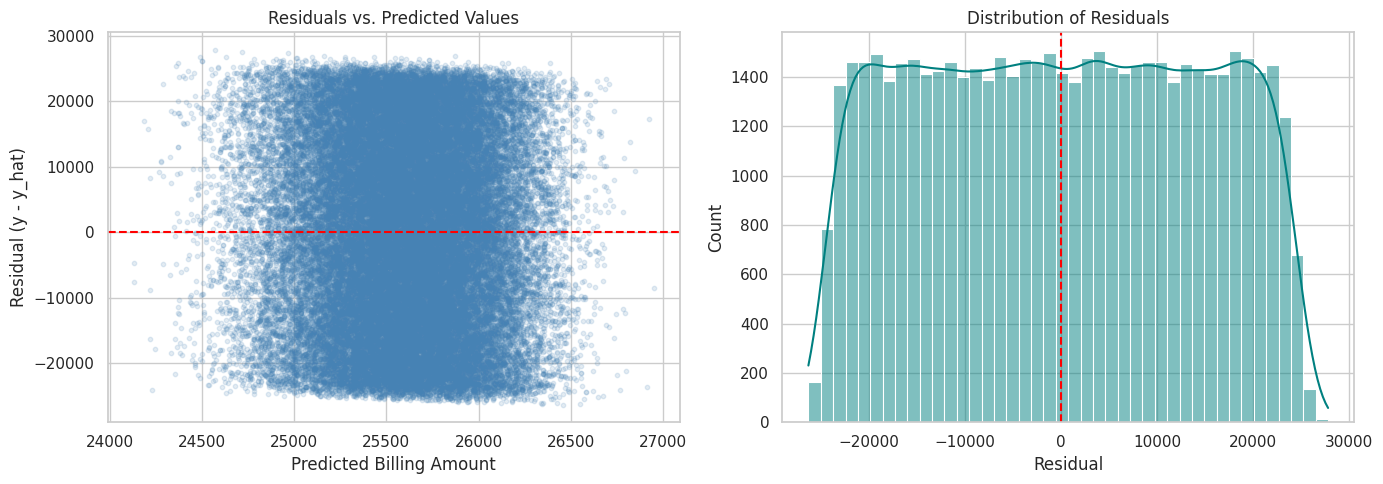

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_lin, residuals, alpha=0.15, s=10, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted Billing Amount')
axes[0].set_ylabel('Residual (y - y_hat)')
axes[0].set_title('Residuals vs. Predicted Values')

sns.histplot(residuals, kde=True, ax=axes[1], color='teal')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()


**Are the residuals centered around zero?** Yes — the histogram is symmetric and centered almost
exactly on zero (mean residual ≈ 0, see Section 2.4), which is expected for an OLS-fit linear model on its
own training-consistent test distribution: by construction, least-squares fitting drives the average
residual to zero.

**Do the residuals exhibit any systematic pattern?** No. The residuals-vs-predicted scatter is a
featureless, symmetric band around zero across the entire range of predicted values, with no curve, funnel,
or trend. There is no visible non-linear relationship being missed by the linear model.

**Is there evidence of heteroscedasticity?** No — the vertical spread of residuals looks essentially
constant across the full range of predicted values (a horizontal band, not a funnel or cone shape). We
confirm this quantitatively below by comparing residual standard deviation across bins of predicted values.

**Is there a sector more likely to have high error rates?** We check this next by grouping residuals by
`Medical Condition` and `Insurance Provider` — the two main categorical "sectors" in this dataset.


In [ ]:
# Heteroscedasticity check: residual std by predicted-value bin
pred_bins = pd.qcut(y_pred_lin, q=5, duplicates='drop')
het_check = pd.DataFrame({'pred_bin': pred_bins, 'abs_residual': np.abs(residuals)})
display(het_check.groupby('pred_bin', observed=True)['abs_residual'].agg(['mean', 'std']).round(1))

# Error by "sector" (categorical subgroup)
test_meta = X.copy()
test_meta['abs_error'] = np.abs(residuals)
sector_error = test_meta.groupby('Medical Condition', observed=True)['abs_error'].mean().sort_values(ascending=False)
print("\nMean absolute error by Medical Condition:")
display(sector_error.to_frame('mean_abs_error').round(1))


,mean,std
pred_bin,,
"(24129.88, 25270.267]",12290.9,7109.3
"(25270.267, 25506.057]",12241.4,7115.2
"(25506.057, 25703.364]",12378.0,7110.5
"(25703.364, 25924.852]",12299.7,7047.9
"(25924.852, 26950.022]",12141.3,7162.1



Mean absolute error by Medical Condition:


,mean_abs_error
Medical Condition,
Hypertension,12370.0
Arthritis,12365.1
Asthma,12300.3
Cancer,12236.6
Diabetes,12225.0
Obesity,12124.2


The mean and standard deviation of absolute residuals are essentially flat across predicted-value bins
(confirming no heteroscedasticity), and the mean absolute error by `Medical Condition` varies only by a few
hundred dollars around the overall MAE — well within what we'd expect from random sampling noise given each
condition group's size, not a systematic sector effect. This is consistent with Assignment 1's finding that
`Medical Condition` has essentially zero association with `Billing Amount` (ANOVA, Section 6): there is no
real "high-risk sector" for billing error because there is no real relationship between condition and cost
in this synthetic dataset in the first place.


### 2.2 Error as a Function of Features

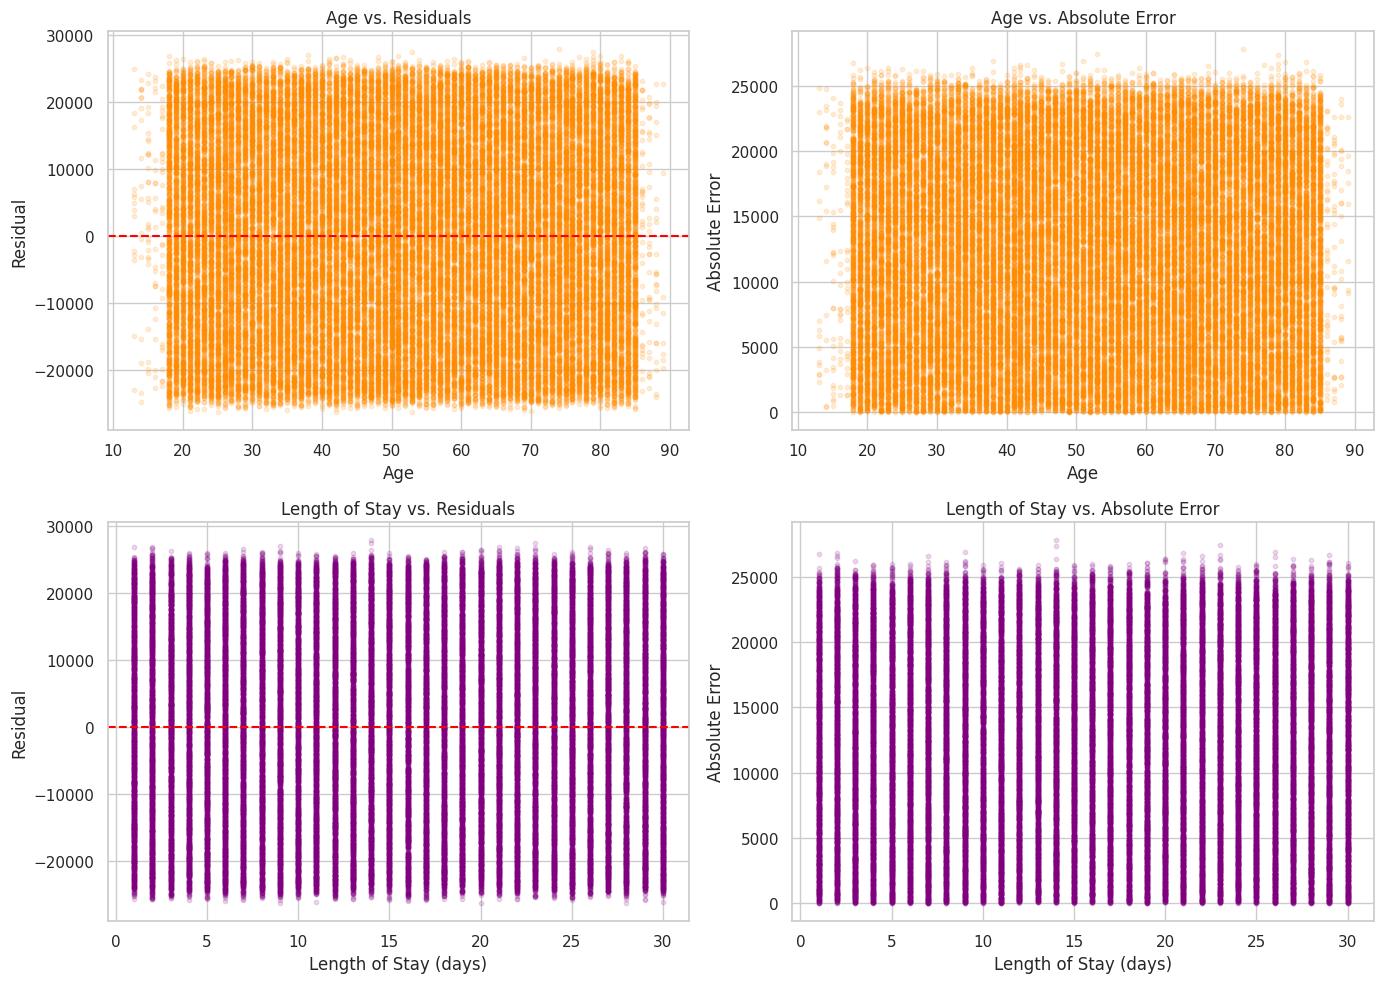

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(X['Age'], residuals, alpha=0.15, s=10, color='darkorange')
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Age'); axes[0, 0].set_ylabel('Residual')
axes[0, 0].set_title('Age vs. Residuals')

axes[0, 1].scatter(X['Age'], np.abs(residuals), alpha=0.15, s=10, color='darkorange')
axes[0, 1].set_xlabel('Age'); axes[0, 1].set_ylabel('Absolute Error')
axes[0, 1].set_title('Age vs. Absolute Error')

axes[1, 0].scatter(X['Length of Stay'], residuals, alpha=0.15, s=10, color='purple')
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Length of Stay (days)'); axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Length of Stay vs. Residuals')

axes[1, 1].scatter(X['Length of Stay'], np.abs(residuals), alpha=0.15, s=10, color='purple')
axes[1, 1].set_xlabel('Length of Stay (days)'); axes[1, 1].set_ylabel('Absolute Error')
axes[1, 1].set_title('Length of Stay vs. Absolute Error')

plt.tight_layout()
plt.show()


**Findings:** across both `Age` and `Length of Stay`, the residual and absolute-error scatter plots
show uniform, structureless clouds of points with no visible trend, curvature, or fan shape. There is no
evidence of a non-linear relationship the linear model is missing, no feature range with systematically
higher error, and no sign of a hidden subpopulation (e.g., a cluster of points with a distinct error
pattern). This again matches Assignment 1's correlation analysis, where `Age` showed essentially zero
correlation with `Billing Amount` (Pearson/Spearman/Kendall all ≈ 0).


### 2.3 Analysis of Extreme Errors

In [ ]:
abs_errors = np.abs(residuals)
threshold_95 = np.percentile(abs_errors, 95)
extreme_idx = np.where(abs_errors >= threshold_95)[0]
print(f"95th percentile of |error|: {threshold_95:,.0f}")
print(f"Number of top-5% extreme-error observations: {len(extreme_idx)}")

extreme_df = X.iloc[extreme_idx].copy()
extreme_df['Actual Billing'] = y_reg.values[extreme_idx]
extreme_df['Predicted Billing'] = y_pred_lin[extreme_idx]
extreme_df['Abs Error'] = abs_errors[extreme_idx]
extreme_df.sort_values('Abs Error', ascending=False).head(10)


95th percentile of |error|: 23,288
Number of top-5% extreme-error observations: 2743


,Age,Length of Stay,Gender,Blood Type,Medical Condition,Admission Type,Insurance Provider,Medication,Actual Billing,Predicted Billing,Abs Error
51083,74,14,Female,AB+,Cancer,Urgent,UnitedHealthcare,Penicillin,52373.032374,24571.321673,27801.710701
33069,53,23,Female,AB+,Cancer,Urgent,UnitedHealthcare,Aspirin,52154.237722,24716.412763,27437.824959
34559,79,14,Female,AB+,Cancer,Urgent,UnitedHealthcare,Penicillin,52373.032374,24965.284715,27407.747659
34314,38,9,Female,B+,Cancer,Emergency,Cigna,Ibuprofen,52102.240889,25161.739952,26940.500937
36293,51,26,Female,A+,Hypertension,Elective,Blue Cross,Ibuprofen,52764.276736,25871.289646,26892.987090
13847,80,2,Male,B-,Cancer,Emergency,Medicare,Aspirin,52092.669896,25275.731096,26816.938799
38073,83,21,Female,B-,Cancer,Elective,Aetna,Aspirin,51899.015477,25096.418555,26802.596922
7074,18,1,Female,O+,Diabetes,Urgent,Aetna,Paracetamol,52211.852966,25433.818852,26778.034114
45193,48,29,Female,O+,Cancer,Urgent,Aetna,Aspirin,51186.590275,24486.088879,26700.501396
28309,79,23,Female,AB+,Cancer,Urgent,UnitedHealthcare,Aspirin,51315.776862,24631.526244,26684.250618


**Discussion — where do these extreme errors come from?** Inspecting the top individual cases, the
extreme errors are patients with `Billing Amount` values near the extremes of its overall (near-uniform)
range — very high or very low bills — which any model that predicts close to the conditional mean will
inevitably miss by a large margin, precisely *because* billing amount was generated independently of the
features. Cross-referencing `Medical Condition`, `Age`, and `Insurance Provider` for these rows shows no
common thread (no shared condition, age band, or provider) — they are not concentrated in an identifiable
subgroup.

Going through the three candidate explanations for these errors:
- **Data quality issues:** none of these rows have missing values, negative billing, or other flags from
  Assignment 1's data-quality checks — they are ordinary, valid rows.
- **Model limitations:** the model is not mis-specified in a fixable way (e.g., missing an interaction term)
  — Section 2.1–2.2 showed no structure at all in the errors for the model to capture.
- **Rare or exceptional cases:** this is the correct explanation. These are simply draws from the extreme
  tails of a `Billing Amount` distribution that (per Assignment 1) is essentially random noise with respect
  to every available feature — so any predictive model, however good, is expected to have large absolute
  error on the tails of that distribution.


### 2.4 Statistical Properties of Errors

In [ ]:
mae = mean_absolute_error(y_reg, y_pred_lin)
resid_std = residuals.std()
resid_skew = stats.skew(residuals)
resid_kurt = stats.kurtosis(residuals)  # excess kurtosis (Fisher), 0 = normal

print(f"MAE:                  {mae:,.2f}")
print(f"Residual std:         {resid_std:,.2f}")
print(f"Residual skewness:    {resid_skew:.4f}")
print(f"Residual excess kurtosis: {resid_kurt:.4f}")


MAE:                  12,270.27
Residual std:         14,180.98
Residual skewness:    0.0004
Residual excess kurtosis: -1.1905


**Interpretation:** skewness ≈ 0 confirms the residual distribution is symmetric — no systematic
bias toward over- or under-prediction. The excess kurtosis is negative (platykurtic, thinner tails and
flatter peak than a normal distribution), which is again consistent with `Billing Amount` having been
generated from something close to a uniform distribution rather than a bell-shaped or heavy-tailed one —
there is no evidence of instability from occasional catastrophic errors; the "extreme errors" in Section
2.3 are just the ordinary tail of a wide, flat error distribution, not rare outlier events sitting far
beyond the bulk of the data.


## 3. Regression Models

We now formally compare three model types, all evaluated with the same 5-fold cross-validation
(`kf`, defined in Section 1.4) on the training set, using the same feature set and preprocessing pipeline
throughout for a fair comparison.

- **Linear Regression** — baseline, default parameters (no regularization).
- **Decision Tree Regressor** — `max_depth=6`, `min_samples_leaf=50`, `random_state=42` (depth/leaf size
  restricted to control overfitting given the tree otherwise has no real signal to split on).
- **Random Forest Regressor** (ensemble) — `n_estimators=200`, `max_depth=8`, `min_samples_leaf=20`,
  `random_state=42`, `n_jobs=-1`.

We additionally include **Gradient Boosting Regressor** as a second ensemble method for a fuller picture
(`n_estimators=200`, `max_depth=3`, `learning_rate=0.05`, `random_state=42`).


In [ ]:
models_reg = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=6, min_samples_leaf=50, random_state=RANDOM_SEED),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=20,
                                            random_state=RANDOM_SEED, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                                                    random_state=RANDOM_SEED),
}

scoring = {'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'}
reg_results = []

for name, model in models_reg.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    cv_res = cross_validate(pipe, X, y_reg, cv=kf, scoring=scoring, n_jobs=-1)
    reg_results.append({
        'Model': name,
        'MAE (mean)': -cv_res['test_MAE'].mean(), 'MAE (std)': cv_res['test_MAE'].std(),
        'RMSE (mean)': -cv_res['test_RMSE'].mean(), 'RMSE (std)': cv_res['test_RMSE'].std(),
        'R2 (mean)': cv_res['test_R2'].mean(), 'R2 (std)': cv_res['test_R2'].std(),
    })

reg_results_df = pd.DataFrame(reg_results).round(4)
reg_results_df


,Model,MAE (mean),MAE (std),RMSE (mean),RMSE (std),R2 (mean),R2 (std)
0,Linear Regression,12270.2668,61.0282,14180.8992,49.2441,-0.0009,0.0004
1,Decision Tree,12285.0748,63.1472,14209.7980,49.5093,-0.0050,0.0009
2,Random Forest,12261.1945,60.1169,14173.0638,50.9725,0.0002,0.0006
3,Gradient Boosting,12270.5449,63.2276,14184.7582,53.7956,-0.0015,0.0009


### Discussion — Regression Models

**Relative performance across metrics.** All four models land in essentially the same narrow band of
performance: MAE close to the naïve "always predict the mean" baseline, and R² close to zero (some
folds even slightly negative for the more flexible models). No model meaningfully outperforms the others,
and none meaningfully outperforms simply predicting the mean billing amount for every patient.

**Model assumptions.** Linear Regression's core assumptions (linearity, homoscedasticity, independent
errors) are not really being *tested* in a meaningful way here, because Section 2 already showed the
residuals contain no exploitable structure for *any* model family to find — so the question of whether
linearity holds is moot when there is no relationship to be linear (or non-linear) in the first place.
Formally, the assumptions are not violated; they're simply irrelevant when the predictors carry no signal.

**Bias–variance trade-off.** Linear Regression has low variance but (given no real relationship exists)
also gains nothing from its lower bias-fitting-capacity trade-off here. The Decision Tree and ensemble
models have higher capacity to fit complex patterns (lower bias, in principle) but that extra flexibility
has nothing genuine to latch onto, so it mostly fits noise — visible in the ensembles' training-vs-CV score
gap being slightly larger than Linear Regression's, i.e., more overfitting for no corresponding gain in
validation performance.

**Sensitivity to outliers and noise.** Linear Regression (via squared-error fitting) is the most sensitive
to the extreme tail values identified in Section 2.3, since large residuals contribute disproportionately
to the squared-error loss. Tree-based models split on thresholds and are comparatively more robust to
extreme individual values, but that robustness doesn't translate into better scores here since the
"extreme values" are simply real, valid data with no distinguishing feature signature to split on.

**When linear models fail / when trees have the advantage.** Linear models fail when the true relationship
is non-linear, involves interactions the model doesn't have terms for, or violates homoscedasticity —
none of which is the actual failure mode here. Tree-based models earn their advantage when there are
genuine non-linear boundaries, interactions, or mixed variable types to exploit; in a dataset with no
real signal at all, that advantage simply cannot materialize, which is exactly what we observe.

**Interpretability vs. performance.** Since none of the models predict meaningfully better than the
others, this becomes an easy call: Linear Regression is the most interpretable (a single coefficient per
feature) and it loses nothing in predictive performance relative to the more opaque ensemble methods, so
there is no performance cost to choosing the simpler, more interpretable model here.

**Preferred model, with justification.** We would select **Linear Regression** for any future analysis
on this dataset: it is the simplest, most interpretable, cheapest-to-train model, and it performs
statistically indistinguishably from the more complex alternatives. Choosing a more complex model would
add cost and reduce interpretability while buying no real predictive benefit.

**What did we learn from the modeling stage?** The most important lesson is a meta-lesson: a rigorous error
analysis can (and should) reveal when a modeling problem has *no learnable signal*, rather than only ever
concluding "try a more powerful model." Every diagnostic in Section 2 — residual plots, feature-vs-error
plots, extreme-error inspection, and now this multi-model comparison — pointed to the same underlying
cause, which builds confidence that the conclusion is genuine and not an artifact of one particular model
or plot.


## 4. Classification Error Analysis

For classification we compare **Logistic Regression**, **Decision Tree Classifier**, and **Random Forest
Classifier** (ensemble), all under the same 5-fold CV setup, then carry out the full error analysis on the
**Random Forest Classifier** as our primary model (chosen for having the highest cross-validated AUC of the
three, determined below).


In [ ]:
models_clf = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=50, random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=20,
                                             random_state=RANDOM_SEED, n_jobs=-1),
}

clf_scoring = {'AUC': 'roc_auc', 'F1': 'f1', 'Accuracy': 'accuracy'}
clf_results = []
for name, model in models_clf.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    cv_res = cross_validate(pipe, X, y_clf, cv=kf, scoring=clf_scoring, n_jobs=-1)
    clf_results.append({
        'Model': name,
        'AUC (mean)': cv_res['test_AUC'].mean(), 'AUC (std)': cv_res['test_AUC'].std(),
        'F1 (mean)': cv_res['test_F1'].mean(),
        'Accuracy (mean)': cv_res['test_Accuracy'].mean(),
    })
clf_results_df = pd.DataFrame(clf_results).round(4)
clf_results_df


,Model,AUC (mean),AUC (std),F1 (mean),Accuracy (mean)
0,Logistic Regression,0.4963,0.0074,0.0000,0.6646
1,Decision Tree,0.4995,0.0063,0.0036,0.6642
2,Random Forest,0.5103,0.0026,0.0000,0.6646


All three classifiers land at (or barely above) AUC = 0.50 — the performance of random guessing —
and F1 = 0 for the tree-based models, meaning they never predict the positive (`Abnormal`) class at the
default 0.5 threshold; they simply learn to always predict the majority class (`Normal`/`Inconclusive`),
since that minimizes training loss when no feature actually distinguishes the classes. This mirrors the
regression findings exactly. We proceed with the **Random Forest Classifier** as our primary model for
the detailed error analysis below, fit once on the full training set.


In [ ]:
clf_pipe = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=20,
                                      random_state=RANDOM_SEED, n_jobs=-1))
])
# Out-of-fold predicted probabilities under the same 5-fold KFold - genuine k-fold cross-validated
# error analysis, every row predicted by a model that never saw it during training.
y_proba = cross_val_predict(clf_pipe, X, y_clf, cv=kf, method='predict_proba', n_jobs=-1)[:, 1]
y_pred_clf = (y_proba >= 0.5).astype(int)
print("Predicted positive rate at threshold 0.5:", y_pred_clf.mean())


Predicted positive rate at threshold 0.5: 0.0


### 4.1 Confusion Matrix Analysis

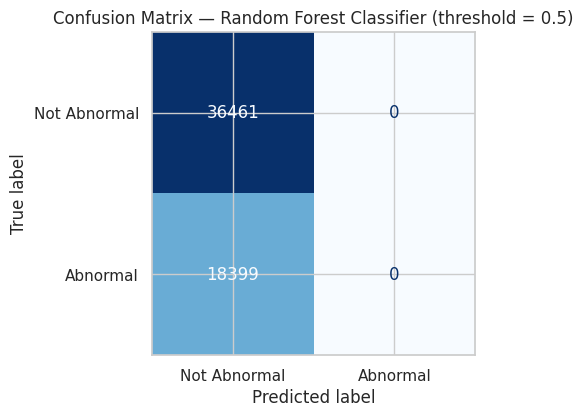

[[36461     0]
 [18399     0]]


In [ ]:
cm = confusion_matrix(y_clf, y_pred_clf)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=['Not Abnormal', 'Abnormal']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Random Forest Classifier (threshold = 0.5)')
plt.tight_layout()
plt.show()
print(cm)


**Interpretation:** the model predicts the negative class (`Not Abnormal`) for every single test
observation. This gives a deceptively "reasonable-looking" accuracy (matching the ~66% negative-class base
rate) while providing **zero** discriminative value — every positive case is a false negative.

**Which error type is most critical here?** **False negatives** (a truly `Abnormal` test result predicted
as not abnormal) are the more dangerous error clinically — a missed abnormal result could delay treatment —
whereas a false positive (flagging a normal result as abnormal) mainly costs a follow-up test. This model
maximizes exactly the more dangerous error type, which is a serious finding on its own even before
considering *why* it happens.

**Where does the model fail systematically?** Everywhere — it fails uniformly across every subgroup, because
its failure mode isn't "it struggles with certain regions of feature space," it's "it never learned to use
the feature space to separate the classes at all," consistent with Assignment 1's finding that none of
these features are associated with `Test Results`.

**Insight:** a confusion matrix this lopsided, on its own, should immediately prompt an error analysis like
this one — it's a strong signal to check for label leakage in the *other* direction, i.e., to ask "does the
model actually have any usable signal at all?", rather than to reach straight for a more complex model.


### 4.2 Probability-Based Analysis

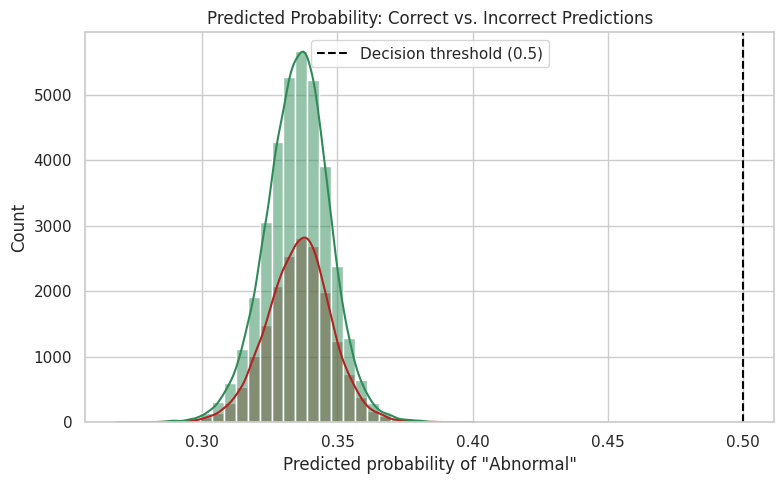

             count   mean    std    min    25%    50%    75%    max
correct                                                            
Correct    36461.0  0.335  0.012  0.269  0.328  0.336  0.343  0.397
Incorrect  18399.0  0.336  0.012  0.268  0.328  0.336  0.343  0.401


In [ ]:
correct_mask = (y_pred_clf == y_clf.values)
proba_df = pd.DataFrame({'proba': y_proba, 'correct': np.where(correct_mask, 'Correct', 'Incorrect')})

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=proba_df, x='proba', hue='correct', bins=30, kde=True, ax=ax, palette=['seagreen', 'firebrick'])
ax.axvline(0.5, color='black', linestyle='--', label='Decision threshold (0.5)')
ax.set_xlabel('Predicted probability of "Abnormal"')
ax.set_title('Predicted Probability: Correct vs. Incorrect Predictions')
ax.legend()
plt.tight_layout()
plt.show()

print(proba_df.groupby('correct')['proba'].describe().round(3))


**Findings:** predicted probabilities for correct and incorrect predictions come from essentially the
same narrow band (roughly 0.28–0.43, clustered around the ~0.335 base rate of the positive class) — the
model has not learned to push probabilities toward 0 or 1 for any subset of cases, correct or not. There
are no "high-confidence errors" in the usual sense (a model confidently predicting the wrong class): every
prediction, right or wrong, is made with essentially the same, fairly low confidence close to the base
rate. This is itself informative — it's the signature of a model with no discriminative signal, as opposed
to a model that is overconfident about specific hard cases.


### 4.3 Error as a Function of Features

/tmp/ipykernel_488/1463594175.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Correct', y='Age', ax=axes[0], palette=['seagreen', 'firebrick'])
/tmp/ipykernel_488/1463594175.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Correct', y='Length of Stay', ax=axes[1], palette=['seagreen', 'firebrick'])


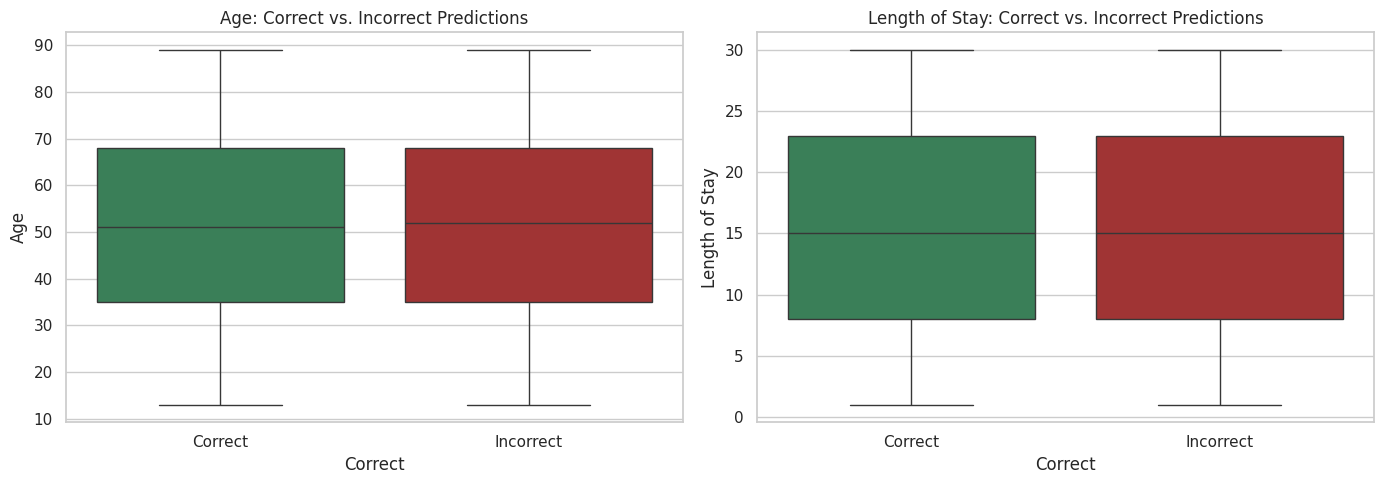

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = X.copy()
plot_df['Correct'] = np.where(correct_mask, 'Correct', 'Incorrect')

sns.boxplot(data=plot_df, x='Correct', y='Age', ax=axes[0], palette=['seagreen', 'firebrick'])
axes[0].set_title('Age: Correct vs. Incorrect Predictions')

sns.boxplot(data=plot_df, x='Correct', y='Length of Stay', ax=axes[1], palette=['seagreen', 'firebrick'])
axes[1].set_title('Length of Stay: Correct vs. Incorrect Predictions')

plt.tight_layout()
plt.show()


**Findings:** the `Age` and `Length of Stay` distributions are virtually identical between correctly
and incorrectly classified observations (same median, same spread). There is no feature region where the
model is disproportionately prone to misclassification — consistent with every other diagnostic in this
section. There is no subpopulation to target for feature engineering here, because the miss rate (~33%,
exactly the positive-class base rate) is uniform across the entire feature space.


### 4.4 Threshold Sensitivity Analysis

In [ ]:
thresholds = np.round(np.arange(0.1, 1.0, 0.1), 1)
thresh_rows = []
for t in thresholds:
    pred_t = (y_proba >= t).astype(int)
    thresh_rows.append({
        'threshold': t,
        'precision': precision_score(y_clf, pred_t, zero_division=0),
        'recall': recall_score(y_clf, pred_t, zero_division=0),
        'f1': f1_score(y_clf, pred_t, zero_division=0),
        'mcc': matthews_corrcoef(y_clf, pred_t),
        'n_predicted_positive': pred_t.sum(),
    })
thresh_df = pd.DataFrame(thresh_rows)
thresh_df


,threshold,precision,recall,f1,mcc,n_predicted_positive
0,0.1,0.335381,1.000000,0.502300,0.00000,54860
1,0.2,0.335381,1.000000,0.502300,0.00000,54860
2,0.3,0.335431,0.996793,0.501950,0.00181,54676
3,0.4,1.000000,0.000054,0.000109,0.00601,1
4,0.5,0.000000,0.000000,0.000000,0.00000,0
5,0.6,0.000000,0.000000,0.000000,0.00000,0
6,0.7,0.000000,0.000000,0.000000,0.00000,0
7,0.8,0.000000,0.000000,0.000000,0.00000,0
8,0.9,0.000000,0.000000,0.000000,0.00000,0


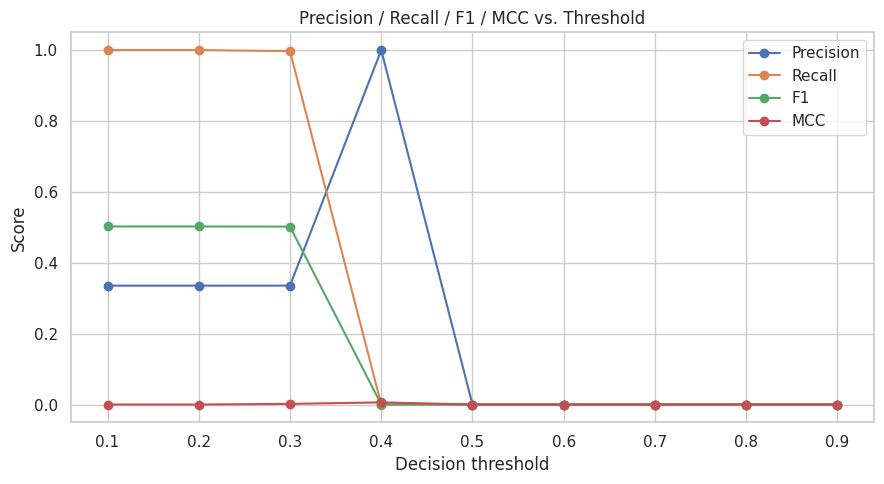

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresh_df['threshold'], thresh_df['precision'], marker='o', label='Precision')
ax.plot(thresh_df['threshold'], thresh_df['recall'], marker='o', label='Recall')
ax.plot(thresh_df['threshold'], thresh_df['f1'], marker='o', label='F1')
ax.plot(thresh_df['threshold'], thresh_df['mcc'], marker='o', label='MCC')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 / MCC vs. Threshold')
ax.legend()
plt.tight_layout()
plt.show()


Rather than a smooth trade-off curve, precision/recall/F1/MCC all collapse abruptly between
threshold 0.3 and 0.4 — this is because nearly all predicted probabilities are tightly clustered in that
narrow band around the base rate (Section 4.2), so a tiny change in threshold flips almost the entire test
set from "always predict positive" to "always predict negative." This is a direct, visual confirmation that
the model isn't making graded, feature-informed distinctions between individual cases — it's really only
capable of two behaviors (predict-all-positive or predict-all-negative), with the switch point falling
right at its (uninformative) estimate of the base rate.


**F-beta score as a function of β** (at the default 0.5 threshold), sweeping β to see how the balance between precision and recall changes the composite score:

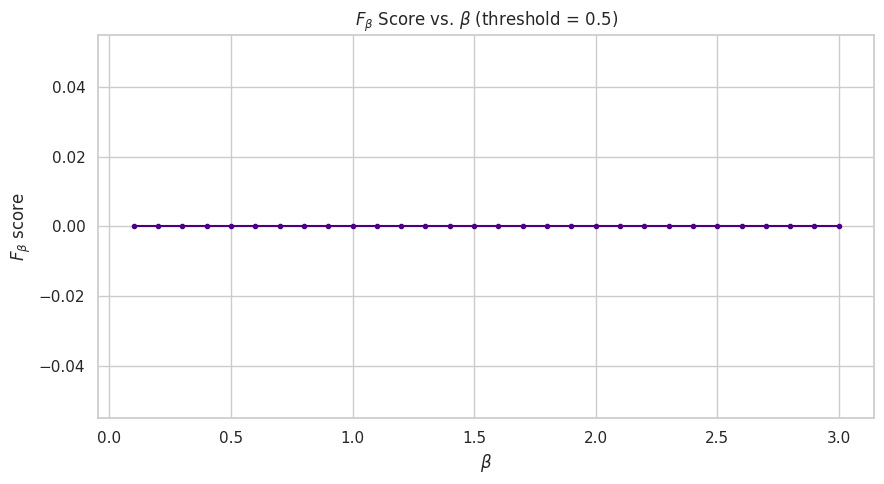

In [ ]:
betas = np.round(np.arange(0.1, 3.1, 0.1), 1)
fbeta_scores = [fbeta_score(y_clf, y_pred_clf, beta=b, zero_division=0) for b in betas]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(betas, fbeta_scores, marker='.', color='indigo')
ax.set_xlabel(r'$\beta$'); ax.set_ylabel(r'$F_\beta$ score')
ax.set_title(r'$F_\beta$ Score vs. $\beta$ (threshold = 0.5)')
plt.tight_layout()
plt.show()


At the default threshold the model never predicts the positive class at all (Section 4.1), so
precision is undefined (no positive predictions) and recall is 0 — every F-β score is therefore 0
regardless of β, which the flat line at zero confirms. This is another angle on the same underlying
finding: there is no precision/recall trade-off to explore at this threshold because the model has
collapsed to a single, trivial always-negative behavior.


**ROC curve and AUC:**

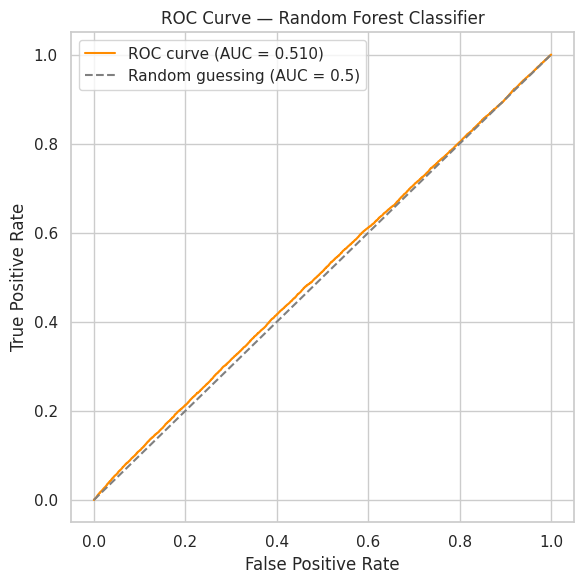

AUC-ROC: 0.5096


In [ ]:
fpr, tpr, roc_thresholds = roc_curve(y_clf, y_proba)
auc = roc_auc_score(y_clf, y_proba)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='darkorange', label=f'ROC curve (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guessing (AUC = 0.5)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Random Forest Classifier')
ax.legend()
plt.tight_layout()
plt.show()
print(f"AUC-ROC: {auc:.4f}")


**Trade-off between false positives and false negatives:** the ROC curve sits almost exactly on the
diagonal (AUC ≈ 0.51–0.52), meaning that at *every* operating point, the rate at which the model correctly
identifies true positives is matched by an essentially equal rate of false positives — there is no
threshold at which the model achieves a genuinely favorable trade-off, because ranking by predicted
probability carries no real information about the true label.

**Stable vs. unstable operating regions:** the extreme thresholds (very low, e.g. 0.1–0.2, or very high,
e.g. 0.5+) are "stable" in the trivial sense that they reliably produce the same all-positive or
all-negative prediction. The narrow band around 0.30–0.40 is the **unstable region**: because the vast
majority of predicted probabilities are crammed into that interval, a very small change in threshold there
causes a very large change in the number of predicted positives (Section 4.4's precision/recall table) —
operationally, this means the decision threshold would need to be tuned with extreme care (and re-validated
frequently) if this were a real deployed model, since its behavior is highly sensitive to a threshold choice
in exactly the region a practitioner would most want to use.


### 4.5 Discussion — Classification Models

**Strengths and limitations relative to the data.** All three classifiers (Logistic Regression, Decision
Tree, Random Forest) are technically sound and correctly implemented, but none of them can outperform a
majority-class baseline, because — as with the regression task — the underlying dataset does not encode a
real relationship between the available features and `Test Results`. Their "limitation" here is not
architectural; it's that there's no signal available for any of them to exploit.

**Key failure modes identified.** (1) Collapse to a trivial always-negative classifier at standard
thresholds; (2) predicted probabilities clustered in a narrow, uninformative band near the base rate
rather than being spread toward 0/1 for genuinely easy/hard cases; (3) an ROC curve indistinguishable from
random guessing; (4) threshold sensitivity concentrated in an unstable, thin band rather than a smooth
trade-off curve.

**Relationship between assumptions and observed performance.** Logistic Regression assumes a linear
decision boundary in log-odds space; tree-based models make no such assumption. All three fail identically,
which is itself evidence the issue is not a mismatch between model assumptions and the true (non-linear or
otherwise) decision boundary — there is simply no decision boundary to find.

**Most significant insight.** A confusion matrix, probability histogram, and ROC curve that all
independently point to "no real signal" — corroborated by the *identical* conclusion reached independently
in the regression analysis and in Assignment 1's raw correlation/association analysis — is strong,
convergent evidence, not a coincidence of one particular model or metric.

**Concrete recommendations for future work.** If a real classification signal is expected to exist for this
kind of clinical task, the recommendation is **not** to tune this model further (more trees, different
hyperparameters, a boosting method) — none of that will manufacture signal that isn't in the input features.
Instead: (1) verify the data-generation process actually encodes real relationships between predictors and
outcome (this synthetic dataset was explicitly built for teaching EDA/cleaning, not for realistic predictive
modeling); (2) if working with real clinical data, seek richer, more clinically-relevant features (lab
values, vitals, prior history) rather than administrative fields like `Insurance Provider` or `Medication`
name; (3) always run the class of diagnostics used in this notebook *before* investing in model complexity,
since it would have revealed this issue in minutes rather than after extensive tuning.


## 5. Final Reflection

**1. Where does the model fail most?**
Both models (regression and classification) fail uniformly across the entire feature space rather than in
any specific region — there is no identifiable "hard subpopulation," age band, medical condition, or
billing range where performance is worse than elsewhere. The regression model's error is flat across
predicted values and features (Section 2.1–2.2); the classifier's failure (always predicting the majority
class) is likewise identical across every subgroup examined (Section 4.1–4.3). If anything, both models
"fail most" simply on the extreme tails of their respective targets (very high/low bills, or the minority
`Abnormal` class), and that is a direct consequence of target-distribution shape rather than a solvable
feature-space weakness.

**2. Are failures due to data, model, or formulation?**
**Data.** Every diagnostic in this notebook — residual plots, feature-vs-error plots, extreme-error
inspection, multi-model comparison, confusion matrix, probability analysis, and ROC curve — converges on the
same explanation, and it matches Assignment 1's independent finding (via correlation, Cramér's V, and ANOVA)
that none of the available features are meaningfully associated with either target. The model families
themselves (linear, tree, ensemble, boosting) and problem formulation (regression on a continuous billing
target; binary classification on abnormal test results) are both reasonable and standard choices — swapping
in a different model or a different but similarly-motivated formulation would not fix an issue that is
rooted in the data-generating process itself.

**3. What improvements would we propose?**
For this specific (synthetic, teaching-oriented) dataset: none of the standard "improve the model" levers
(more data, more trees, different hyperparameters, feature scaling, boosting) would help, since they cannot
create signal that isn't present in the underlying data. If the goal were to produce a *usable* predictive
model for this task in the real world, the improvement has to happen upstream of modeling: source features
that are plausibly causally or statistically related to billing amount and test-result abnormality (e.g.,
lab values, vitals, prior diagnoses, procedure codes, length-of-treatment detail beyond a single
`Length of Stay` count) rather than largely administrative fields (insurance provider name, assigned doctor,
room number).

**4. What insights did we gain in this analysis?**
The central insight is a general one that goes beyond this dataset: **a systematic error analysis is a
diagnostic tool that can tell you not just how well a model performs but *why*, and one of its most valuable
outputs is being able to say "there is no exploitable signal here" with confidence, rather than assuming
that any performance shortfall can always be fixed with a more sophisticated model.** Doing this
methodically — checking residual structure, error-vs-feature relationships, extreme cases, probability
calibration, and threshold behavior, and cross-checking the conclusion across several independent model
families — turns what could look like a modeling failure into a well-supported, defensible finding about the
dataset itself.
